# 📝 Proyecto: Clasificador de Vinos con KNN
Entrenaremos un modelo de **K-Nearest Neighbors (KNN)** para predecir la calidad de un vino tinto a partir de sus características químicas. ¿Podría una IA ayudarte a elegir un vino digno de sommelier?

### 📊 Dataset
Utilizaremos el dataset de vinos tintos de la UCI:
[Wine Quality Data Set](https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv)

**Descripción de columnas:**
* **Composición química:** `fixed acidity`, `volatile acidity`, `citric acid`, `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, `density`, `pH`, `sulphates`, `alcohol`.
* **Objetivo (label):** 
    * `0`: Baja calidad
    * `1`: Calidad media
    * `2`: Alta calidad

In [268]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [269]:
# Cargamos el dataset de playstore_reviews
df=pd.read_csv("../data/raw/winequality-red.csv", delimiter = ";")
df.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5


In [270]:
#chekamos la info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [271]:
#Obtenemos que columnas tienen valores unicos y su porcentage respectivamente
print("------------------PORCENTAJE DE VALORES UNICOS DEL df---------------------\n")
info_uniques = pd.DataFrame({
    'Valores Únicos': df.nunique(),
    'Total Filas': len(df),
    '% Unicidad': (df.nunique() / len(df)) * 100
}).sort_values(by = '% Unicidad', ascending = False)
info_uniques

------------------PORCENTAJE DE VALORES UNICOS DEL df---------------------



,Valores Únicos,Total Filas,% Unicidad
density,436,1599,27.267042
chlorides,153,1599,9.568480
total sulfur dioxide,144,1599,9.005629
volatile acidity,143,1599,8.943089
fixed acidity,96,1599,6.003752
sulphates,96,1599,6.003752
residual sugar,91,1599,5.691057
pH,89,1599,5.565979
citric acid,80,1599,5.003127
alcohol,65,1599,4.065041


In [272]:
df.describe(include = 'all').T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [273]:
df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

## Analisis Hasta Ahora:
* Tenemos un dataframe de datos de reviews con 1599 filas y 12 columnas.
* 12 Columnas son float y 1 INT.
* `quality` es nustro target que son valores 0 o 1.
* Podemos ver que algunas variables tiene outliers por ejemplo `total sulfur dioxide` tiene una desviacion estandar de 32, una media de 46 y un valor maximo de 289, algo parecido pasa con otras como el `pH`

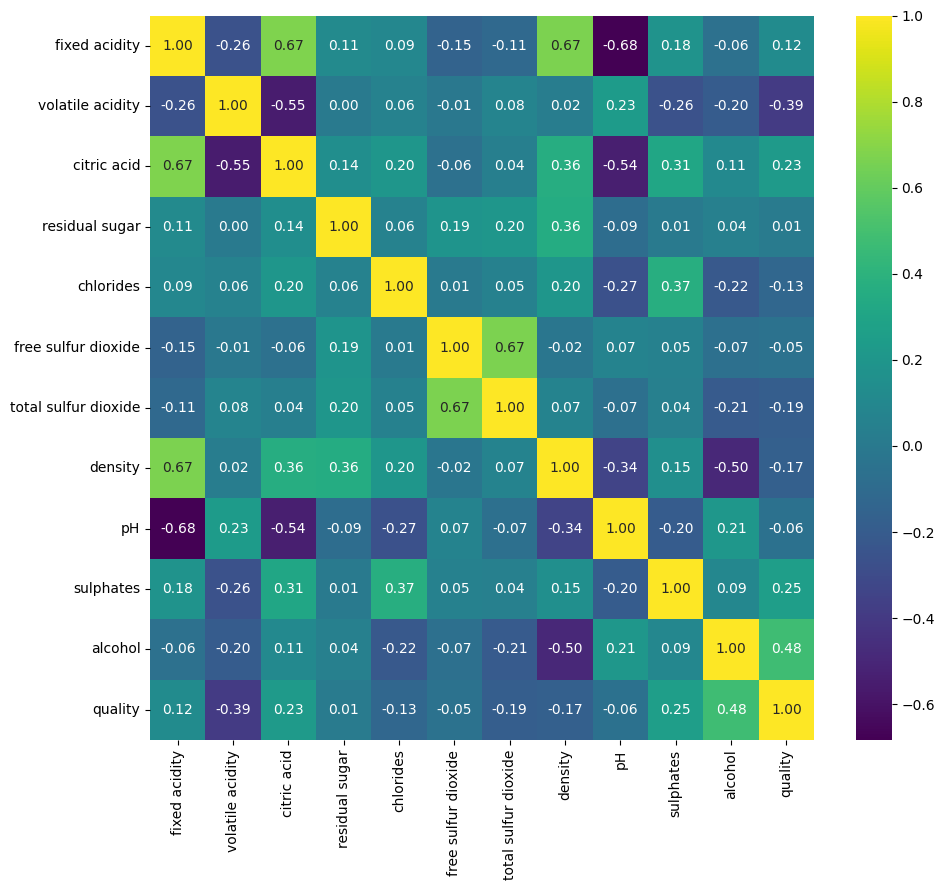

In [274]:
#Vamos a dibujar un heatmap para ver correlaciones ya que todas nuestras variables son numericas.
cols_num = df.select_dtypes(include = ['number']).columns
fig, ax = plt.subplots(figsize = (10,  9))
sns.heatmap(df[cols_num].corr(method = "pearson"), annot = True, fmt = ".2f", cmap = "viridis", ax = ax)
plt.tight_layout()
plt.show()

## Analisis del heatmap
* Con respecto a nuestro target el MVP es la variable `alcohol` con un 0.48 vamos a intentar hacer un filtrado rapido, desde 0.17 hasta 0.48.
* `fixed acidity` tiene una correlacion baja de 0.12, aunque es baja quizas podramos hacer algo con ella quizas conbinarla con el pH que tiene una correlacion con esta misma de -0.68, aunque primero vamos a probar el modelo sin hacer esto.

In [275]:
# Como dijimos vamos a combinar fixed acidity con el pH vamos a intentar hacer dos cosas multiplicarlos y dividirlos entre si a ver cual nos arroja mejor resultado.
df['acid_ph_ratio'] = df['fixed acidity'] / df['pH']
df['acid_interaction'] = df['fixed acidity'] * df['pH']
target = df.pop('quality')
df['quality'] = target

In [ ]:
#Hacemos el filtrado rapido con "between"
correlaciones = df.corr()['quality'].sort_values(ascending = False)
correlaciones = correlaciones[correlaciones.abs().between(0.16, 0.49)]
df_corr = pd.concat([df[correlaciones.index], df['quality']], axis = 1)
df_corr["acid_interaction"]=df["acid_interaction"]
df_corr

,alcohol,sulphates,citric acid,density,total sulfur dioxide,volatile acidity,quality,acid_interaction
0,9.4,0.56,0.00,0.99780,34.0,0.700,5,25.974
1,9.8,0.68,0.00,0.99680,67.0,0.880,5,24.960
2,9.8,0.65,0.04,0.99700,54.0,0.760,5,25.428
3,9.8,0.58,0.56,0.99800,60.0,0.280,6,35.392
4,9.4,0.56,0.00,0.99780,34.0,0.700,5,25.974
...,...,...,...,...,...,...,...,...
1594,10.5,0.58,0.08,0.99490,44.0,0.600,5,21.390
1595,11.2,0.76,0.10,0.99512,51.0,0.550,6,20.768
1596,11.0,0.75,0.13,0.99574,40.0,0.510,6,21.546
1597,10.2,0.71,0.12,0.99547,44.0,0.645,5,21.063


In [277]:
# no nos olvidemos que nos piden una prediccion entre 3 opciones calidad baja, media y alta por lo que vamos a intentar agruparlos inteligentemente para tener un support decente
# en las tres categorias. 
# Le estamos diciendo que 0 va a estar entre 0-5, 1 va a ser 6, y 3 va a estar entre 7 y 10.
df_corr['quality'] = pd.cut(df['quality'], bins=[0, 5, 6, 10], labels=[0, 1, 2])
df_corr['quality'].value_counts()
# Por cierto hacemos esto despues del heatmap porque para el mismo nos viene mejor los datos originales (calidad 3, 4, 5, 6, 7, 8), ya que argupando perdemos sensibilidad.

quality
0    744
1    638
2    217
Name: count, dtype: int64

In [278]:
#Separamos nuestro dataframe en X e y
X = df_corr.drop('quality',axis = 1)
y = df_corr['quality']
X.head()

,alcohol,sulphates,citric acid,density,total sulfur dioxide,volatile acidity,acid_interaction
0,9.4,0.56,0.00,0.9978,34.0,0.70,25.974
1,9.8,0.68,0.00,0.9968,67.0,0.88,24.960
2,9.8,0.65,0.04,0.9970,54.0,0.76,25.428
3,9.8,0.58,0.56,0.9980,60.0,0.28,35.392
4,9.4,0.56,0.00,0.9978,34.0,0.70,25.974


In [279]:
#Dividimos en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [280]:
#Segun lo que vimos en clases a diferencia de random forest aqui si es mucho muy importante scalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [281]:
#Hacemos una primera prueba del modelo KNeighborsClassifier con n_neighbors = 5
model_knn = KNeighborsClassifier(n_neighbors = 5, metric = "manhattan")
model_knn.fit(X_train_scaled, y_train)
predict_knn = model_knn.predict(X_test_scaled)
metrics_knn = classification_report(y_test, predict_knn, output_dict = True)
print(classification_report(y_test, predict_knn))

              precision    recall  f1-score   support

           0       0.65      0.77      0.71       141
           1       0.58      0.53      0.55       132
           2       0.62      0.43      0.51        47

    accuracy                           0.62       320
   macro avg       0.62      0.58      0.59       320
weighted avg       0.62      0.62      0.61       320



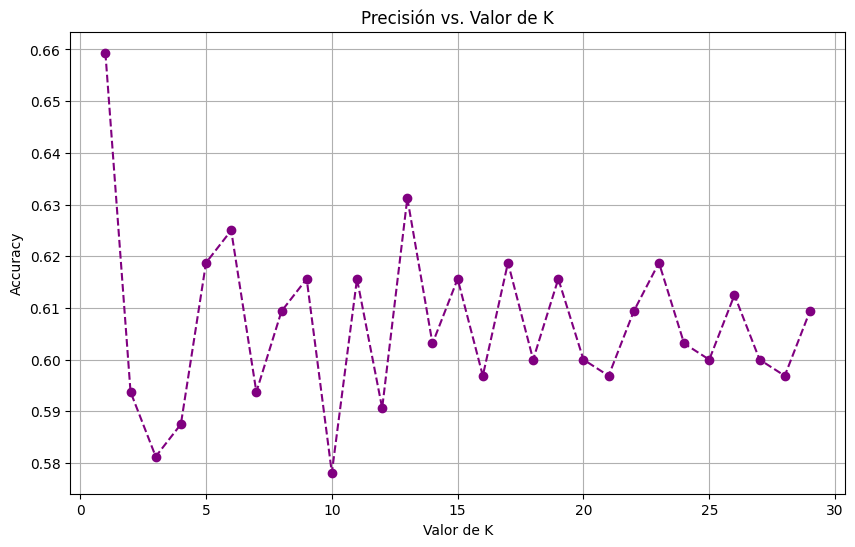

In [282]:
#Tenemos un rendimiento general de 0.62, vamos a dibujar un "brazo" para ver si vemos un "codo".
accuracies = []
# Probamos K's del 1 al 30 y lo metemos en un bucle
k_range = range(1, 30)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(knn.score(X_test_scaled, y_test))


plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='purple')
plt.title('Precisión vs. Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


# Analisis del grafico:
Se logra apreciar un brazo pero fracturado digamos, vamos a ver si podemos hacer unos ajustes para mejorar el modelo y superar el 0.62 de redimiento del modelo.
Entre ellos vamos a ver si podemos modificar columnas antes de meternos en el modelo y luego buscamos con un RamdonGridSearch y GridSearch para encontrar los mejores parametros

In [283]:
from sklearn.neighbors import KNeighborsClassifier

# Definimos el modelo base
knn = KNeighborsClassifier()

# Creamos el "grid" de parámetros
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15], # Es recomendable usar números impares para evitar empates
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'leaf_size': [20, 30, 40] # Opcional: afecta la velocidad de búsqueda del algoritmo
}

# Configuramos el GridSearch
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Ajustamos a los datos
grid_search.fit(X_train_scaled, y_train)
model_grid = grid_search.best_estimator_
score  = cross_val_score(model_grid, X, y, cv=5, scoring='accuracy')
print(f"Mejor score: {grid_search.best_score_}")
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"F1-score medio: {score.mean():.3f}")
print(f"Desviación estándar: {score.std():.3f}")

Mejor score: 0.6896323529411765
Mejores parámetros: {'leaf_size': 20, 'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
F1-score medio: 0.528
Desviación estándar: 0.023


In [284]:
model_grid.fit(X_train_scaled, y_train)
predict_grid = grid_search.predict(X_test_scaled)
metrics_grid = classification_report(y_test, predict_grid, output_dict = True)
print(classification_report(y_test, predict_grid))

              precision    recall  f1-score   support

           0       0.75      0.83      0.79       141
           1       0.67      0.63      0.65       132
           2       0.67      0.60      0.63        47

    accuracy                           0.71       320
   macro avg       0.70      0.68      0.69       320
weighted avg       0.71      0.71      0.71       320



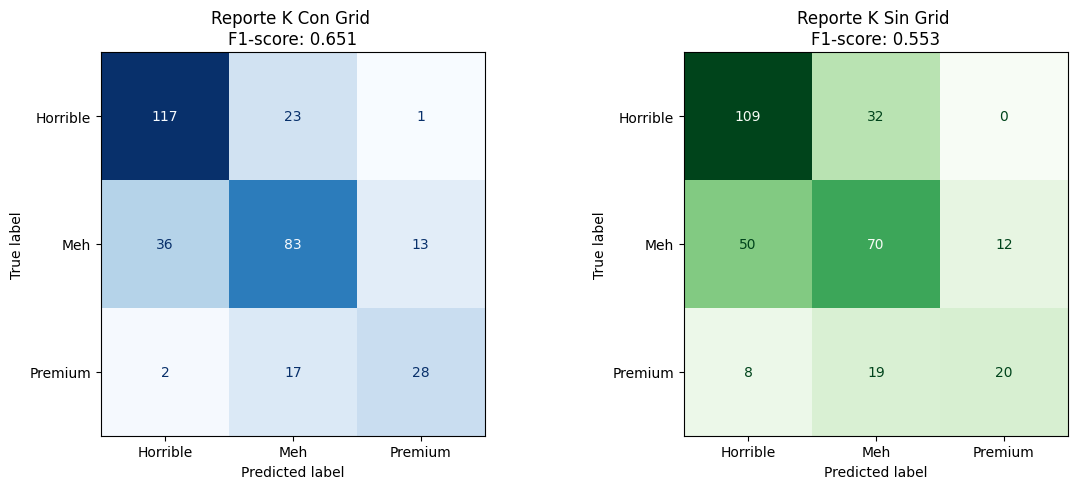

In [285]:
# Vamos ahora a comparar ambas predicciones con una matriz de confucion
nombres_clases = ["Horrible", "Meh", "Premium"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# REPORTE CON EL GRID
cm_grid = confusion_matrix(y_test, predict_grid)
disp_grid = ConfusionMatrixDisplay(confusion_matrix=cm_grid, display_labels=nombres_clases)
disp_grid.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title(f"Reporte K Con Grid \nF1-score: {metrics_grid['1']['f1-score']:.3f}")

# MultinomialNB
cm_knn = confusion_matrix(y_test, predict_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=nombres_clases)
disp_knn.plot(ax=ax2, cmap='Greens', colorbar=False)
ax2.set_title(f"Reporte K Sin Grid \nF1-score: {metrics_knn['1']['f1-score']:.3f}")


plt.tight_layout()
plt.show()

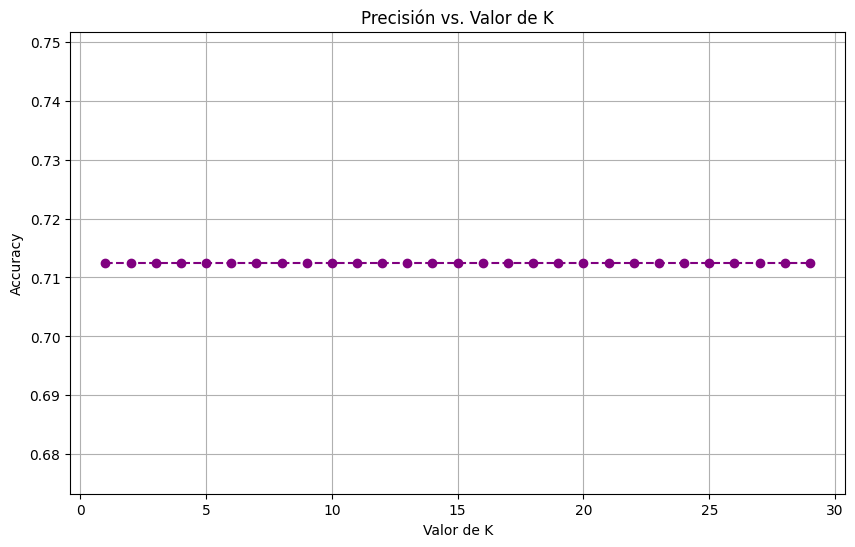

El mejor valor de k es: 1


In [286]:
accuracies = []
k_range = range(1, 30)

for k in k_range:
  
    accuracies.append(model_grid.score(X_test_scaled, y_test))

# Gráfica Visual
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracies, marker='o', linestyle='--', color='purple')
plt.title('Precisión vs. Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Elegimos el mejor k (el que tenga mayor accuracy)
best_k = k_range[np.argmax(accuracies)]
print(f"El mejor valor de k es: {best_k}")